In [1]:
import nltk
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
df = pd.read_csv("C:\\Users\\ASH\\Desktop\\NLP.csv", encoding="latin1")


# EDA

In [3]:
df.head()

,id,comment_text,split,created_date,publication_id,parent_id,article_id,rating,funny,wow,...,physical_disability,intellectual_or_learning_disability,psychiatric_or_mental_illness,other_disability,identity_annotator_count,toxicity_annotator_count,toxic,severe_toxic,identity_hate,lang
0,1083994,He got his money... now he lies in wait till a...,train,2017-03-06 15:21:53.675241+00,21,NaN,317120,approved,0,0,...,NaN,NaN,NaN,NaN,0,67,NaN,NaN,NaN,NaN
1,650904,Mad dog will surely put the liberals in mental...,train,2016-12-02 16:44:21.329535+00,21,NaN,154086,approved,0,0,...,NaN,NaN,NaN,NaN,0,76,NaN,NaN,NaN,NaN
2,5902188,And Trump continues his lifelong cowardice by ...,train,2017-09-05 19:05:32.341360+00,55,NaN,374342,approved,1,0,...,NaN,NaN,NaN,NaN,0,63,NaN,NaN,NaN,NaN
3,7084460,"""while arresting a man for resisting arrest"".\...",test,2016-11-01 16:53:33.561631+00,13,NaN,149218,approved,0,0,...,NaN,NaN,NaN,NaN,0,76,NaN,NaN,NaN,NaN
4,5410943,Tucker and Paul are both total bad ass mofo's.,train,2017-06-14 05:08:21.997315+00,21,NaN,344096,approved,0,0,...,NaN,NaN,NaN,NaN,0,80,NaN,NaN,NaN,NaN


In [4]:
df.columns

Index(['id', 'comment_text', 'split', 'created_date', 'publication_id',
       'parent_id', 'article_id', 'rating', 'funny', 'wow', 'sad', 'likes',
       'disagree', 'toxicity', 'severe_toxicity', 'obscene', 'sexual_explicit',
       'identity_attack', 'insult', 'threat', 'male', 'female', 'transgender',
       'other_gender', 'heterosexual', 'homosexual_gay_or_lesbian', 'bisexual',
       'other_sexual_orientation', 'christian', 'jewish', 'muslim', 'hindu',
       'buddhist', 'atheist', 'other_religion', 'black', 'white', 'asian',
       'latino', 'other_race_or_ethnicity', 'physical_disability',
       'intellectual_or_learning_disability', 'psychiatric_or_mental_illness',
       'other_disability', 'identity_annotator_count',
       'toxicity_annotator_count', 'toxic', 'severe_toxic', 'identity_hate',
       'lang'],
      dtype='object')

In [5]:
df.shape

(1048575, 50)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 50 columns):
 #   Column                               Non-Null Count    Dtype  
---  ------                               --------------    -----  
 0   id                                   1048575 non-null  int64  
 1   comment_text                         1048573 non-null  object 
 2   split                                1048575 non-null  object 
 3   created_date                         1048575 non-null  object 
 4   publication_id                       1048575 non-null  int64  
 5   parent_id                            595626 non-null   float64
 6   article_id                           1048575 non-null  int64  
 7   rating                               1048575 non-null  object 
 8   funny                                1048575 non-null  int64  
 9   wow                                  1048575 non-null  int64  
 10  sad                                  1048575 non-null  int64  
 11

In [7]:
null_counts = df.isnull().sum()

In [8]:
null_counts

id                                           0
comment_text                                 2
split                                        0
created_date                                 0
publication_id                               0
parent_id                               452949
article_id                                   0
rating                                       0
funny                                        0
wow                                          0
sad                                          0
likes                                        0
disagree                                     0
toxicity                                     0
severe_toxicity                              0
obscene                                      0
sexual_explicit                              0
identity_attack                              0
insult                                       0
threat                                       0
male                                    987132
female       

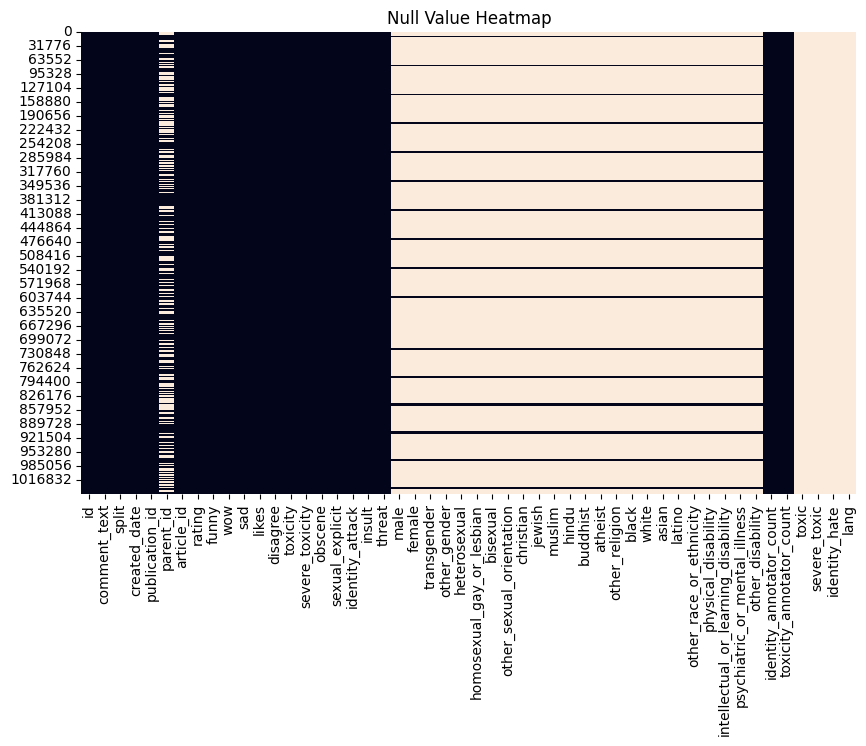

In [15]:
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Null Value Heatmap")
plt.show()

In [9]:
# impute misssing values in comment_text column
df["comment_text"] = df["comment_text"].fillna("")

In [10]:
df.isnull().sum()

id                                           0
comment_text                                 0
split                                        0
created_date                                 0
publication_id                               0
parent_id                               452949
article_id                                   0
rating                                       0
funny                                        0
wow                                          0
sad                                          0
likes                                        0
disagree                                     0
toxicity                                     0
severe_toxicity                              0
obscene                                      0
sexual_explicit                              0
identity_attack                              0
insult                                       0
threat                                       0
male                                    987132
female       

# Select column

In [11]:
df = pd.read_csv(r"C:\Users\ASH\Desktop\NLP.csv", encoding="latin1")
df = df[["comment_text", "sexual_explicit"]]

In [12]:
df.head()

,comment_text,sexual_explicit
0,He got his money... now he lies in wait till a...,0.014925
1,Mad dog will surely put the liberals in mental...,0.013158
2,And Trump continues his lifelong cowardice by ...,0.000000
3,"""while arresting a man for resisting arrest"".\...",0.592105
4,Tucker and Paul are both total bad ass mofo's.,0.275000


In [13]:
print("Text Column:\n")
print(df["comment_text"].head())

Text Column:

0    He got his money... now he lies in wait till a...
1    Mad dog will surely put the liberals in mental...
2    And Trump continues his lifelong cowardice by ...
3    "while arresting a man for resisting arrest".\...
4       Tucker and Paul are both total bad ass mofo's.
Name: comment_text, dtype: object


# STEP 1 — Minimal Cleaning

In [14]:
import re

def clean_text(text):
    text = str(text).lower()                 # lowercase
    text = re.sub(r"\s+", " ", text)        # replace multiple spaces/newlines with one
    text = text.strip()                      # remove leading/trailing spaces
    return text

df["text_clean"] = df["comment_text"].apply(clean_text)

In [15]:
print(df["text_clean"].head())

0    he got his money... now he lies in wait till a...
1    mad dog will surely put the liberals in mental...
2    and trump continues his lifelong cowardice by ...
3    "while arresting a man for resisting arrest". ...
4       tucker and paul are both total bad ass mofo's.
Name: text_clean, dtype: object


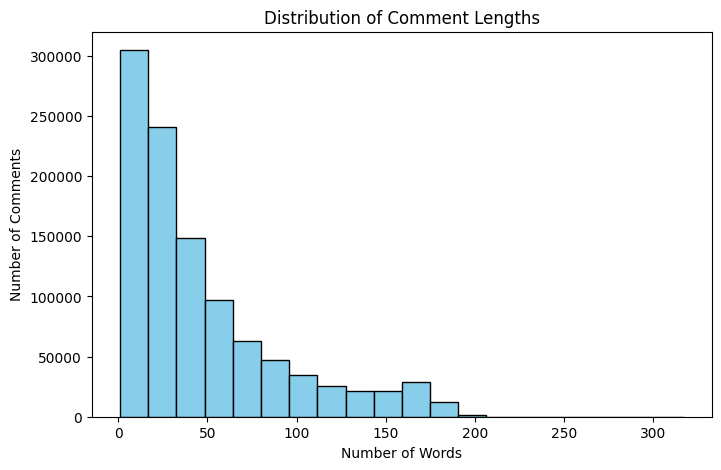

In [22]:
import matplotlib.pyplot as plt

# Compute length of each comment
df['comment_length'] = df['text_clean'].apply(lambda x: len(x.split()))

# Plot histogram
plt.figure(figsize=(8,5))
plt.hist(df['comment_length'], bins=20, color='skyblue', edgecolor='black')
plt.xlabel("Number of Words")
plt.ylabel("Number of Comments")
plt.title("Distribution of Comment Lengths")
plt.show()

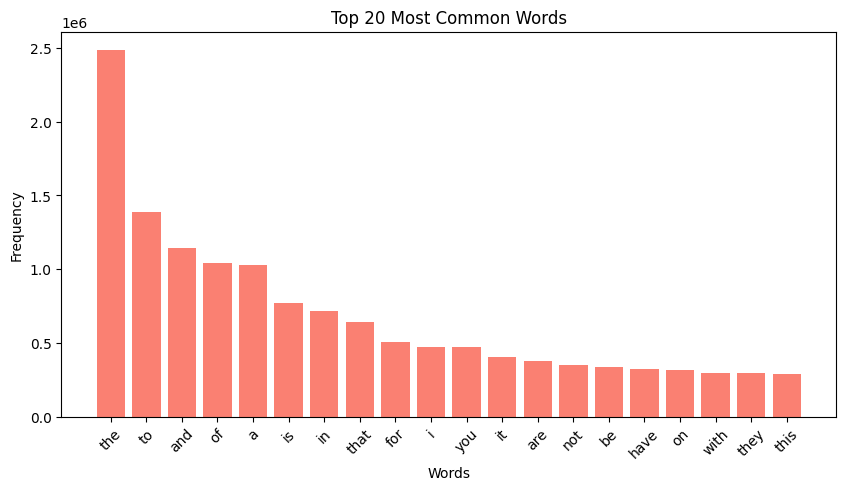

In [21]:
from collections import Counter
from itertools import chain

# Split all comments into words
all_words = list(chain(*df['text_clean'].str.split()))

# Count top 20 words
word_counts = Counter(all_words).most_common(20)

words, counts = zip(*word_counts)

# Plot bar chart
plt.figure(figsize=(10,5))
plt.bar(words, counts, color='salmon')
plt.xticks(rotation=45)
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.title("Top 20 Most Common Words")
plt.show()

In [16]:
print("Sexual Explicit Column:\n")
print(df["sexual_explicit"].describe())

Sexual Explicit Column:

count    1.048575e+06
mean     4.144650e-03
std      4.053963e-02
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.000000e+00
Name: sexual_explicit, dtype: float64


In [17]:
# Show first few rows
print(df["sexual_explicit"].head())

# Show value counts
print(df["sexual_explicit"].value_counts())

0    0.014925
1    0.013158
2    0.000000
3    0.592105
4    0.275000
Name: sexual_explicit, dtype: float64
sexual_explicit
0.000000    1017494
0.166667       1884
0.012500       1319
0.014286       1198
0.013158        914
             ...   
0.835821          1
0.013707          1
0.001207          1
0.529412          1
0.854305          1
Name: count, Length: 1967, dtype: int64


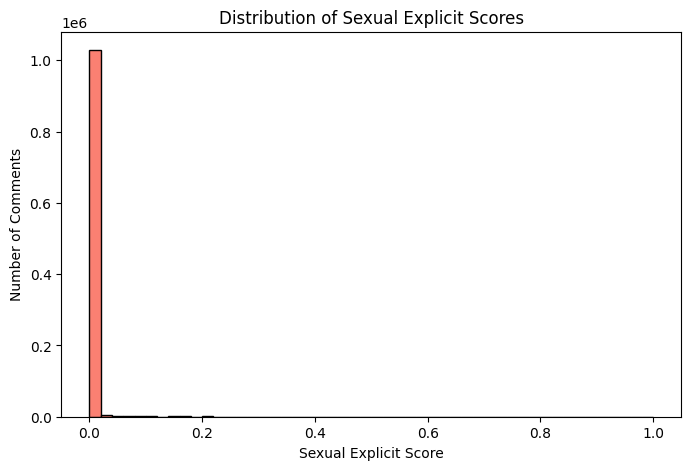

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df['sexual_explicit'], bins=50, color='salmon', edgecolor='black')
plt.xlabel("Sexual Explicit Score")
plt.ylabel("Number of Comments")
plt.title("Distribution of Sexual Explicit Scores")
plt.show()

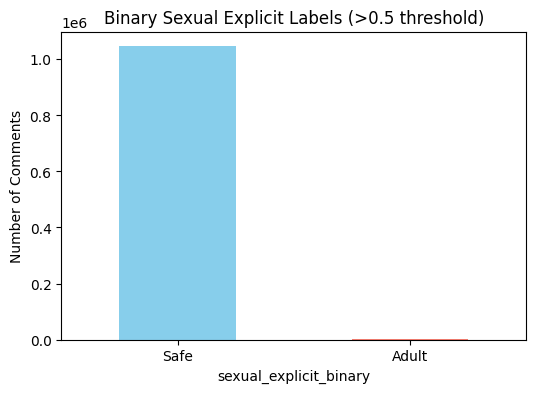

In [19]:
df['sexual_explicit_binary'] = (df['sexual_explicit'] > 0.5).astype(int)

plt.figure(figsize=(6,4))
df['sexual_explicit_binary'].value_counts().plot(kind='bar', color=['skyblue','salmon'])
plt.xticks([0,1], ['Safe', 'Adult'], rotation=0)
plt.ylabel("Number of Comments")
plt.title("Binary Sexual Explicit Labels (>0.5 threshold)")
plt.show()

In [23]:
# Filter comments with high sexual explicit score
adult_comments = df[df['sexual_explicit'] > 0.5]['text_clean']

# Split into words
adult_words = list(chain(*adult_comments.str.split()))

# Show first 50 words
print(adult_words[:50])

['"while', 'arresting', 'a', 'man', 'for', 'resisting', 'arrest".', 'if', 'you', 'cop-suckers', "can't", 'see', 'a', 'problem', 'with', 'this,', 'then', 'go', 'suck', 'the', 'barrel', 'of', 'a', 'glock.', 'what', 'an', 'ugly', 'orgy.', 'shame', 'on', 'fish', 'and', 'game', 'for', 'allowing', 'this.', 'how', 'many', 'ways', 'can', 'we', 'devise', 'to', 'exploit', 'a', 'resource...............shame', 'on', 'us.', 'headline', 'porn!']


In [21]:
from collections import Counter

word_counts = Counter(adult_words)
print(word_counts.most_common(20))  # Top 20 words

[('the', 2818), ('to', 1857), ('a', 1818), ('and', 1639), ('of', 1270), ('you', 1267), ('is', 1128), ('that', 863), ('in', 858), ('i', 742), ('your', 731), ('for', 648), ('with', 578), ('it', 532), ('are', 532), ('have', 503), ('not', 493), ('he', 492), ('on', 465), ('his', 454)]


#  Convert to Binary

In [24]:
df["label"] = (df["sexual_explicit"] > 0.5).astype(int)

# Check Imbalance

In [25]:
print(df["label"].value_counts())

label
0    1046298
1       2277
Name: count, dtype: int64


#  Check Imbalance Ratio

In [26]:
ratio = 2277 / 1046298
print(f"Adult fraction: {ratio:.4f}")

Adult fraction: 0.0022


# STEP 2 —Balance

In [27]:
df_majority = df[df.label == 0]
df_minority = df[df.label == 1]

# Keep 5x more normal than adult
df_majority_sample = df_majority.sample(n=len(df_minority)*5, random_state=42)

df_balanced = pd.concat([df_majority_sample, df_minority])
df_balanced = df_balanced.sample(frac=1, random_state=42)

In [28]:
print(df_balanced.label.value_counts())

label
0    11385
1     2277
Name: count, dtype: int64


# Step 3 —Proper Train/Test Split

In [29]:
from sklearn.model_selection import train_test_split

train_texts, val_texts, train_labels, val_labels = train_test_split(
    df_balanced["text_clean"],
    df_balanced["label"],
    test_size=0.2,
    stratify=df_balanced["label"],
    random_state=42
)

# Step 4 — Load Tokenizer

In [30]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

train_encodings = tokenizer(
    list(train_texts),
    truncation=True,
    padding=True,
    max_length=128
)

val_encodings = tokenizer(
    list(val_texts),
    truncation=True,
    padding=True,
    max_length=128
)

c:\Users\ASH\download\envs\NLP_tf_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [31]:
print(train_encodings.keys())

dict_keys(['input_ids', 'attention_mask'])


# Step 5 -- Convert to TensorFlow Dataset

In [32]:
import tensorflow as tf

train_dataset = tf.data.Dataset.from_tensor_slices((
    dict(train_encodings),
    train_labels.values
)).shuffle(1000).batch(16)

val_dataset = tf.data.Dataset.from_tensor_slices((
    dict(val_encodings),
    val_labels.values
)).batch(16)

# STEP 6 — Load Model

In [33]:
import transformers
print(transformers.__version__)

4.41.2


In [34]:
from transformers import TFAutoModelForSequenceClassification

model = TFAutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertForSequenceClassification: ['vocab_layer_norm.weight', 'vocab_transform.weight', 'vocab_layer_norm.bias', 'vocab_projector.bias', 'vocab_transform.bias']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFDistilBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['pre_classifier.weight', 'pre_classifier.bias', 'classifier.weight', 'classifier.bias']
You should 

# STEP 7 —Compile Model

In [35]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy

optimizer = Adam(learning_rate=2e-5)

loss = SparseCategoricalCrossentropy(from_logits=True)

model.compile(
    optimizer=optimizer,
    loss=loss,
    metrics=["accuracy"]
)

# STEP 8 — Training Setup

In [36]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=1
)

684/684 [==============================] - 12058s 17s/step - loss: 0.1124 - accuracy: 0.9614 - val_loss: 0.0581 - val_accuracy: 0.9813


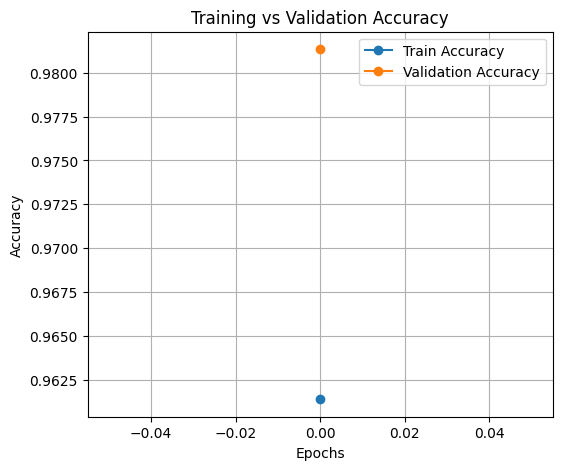

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.plot(history.history['accuracy'], marker='o', label='Train Accuracy')
plt.plot(history.history['val_accuracy'], marker='o', label='Validation Accuracy')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid()

plt.show()

# STEP 9 — Evaluation Metric

In [38]:
from sklearn.metrics import classification_report

# Get predictions
logits = model.predict(val_dataset).logits

preds = np.argmax(logits, axis=1)

print(classification_report(val_labels.values, preds))

171/171 [==============================] - 803s 5s/step
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2278
           1       0.94      0.95      0.94       455

    accuracy                           0.98      2733
   macro avg       0.96      0.97      0.97      2733
weighted avg       0.98      0.98      0.98      2733



Confusion Matrix:
[[2248   30]
 [  21  434]]


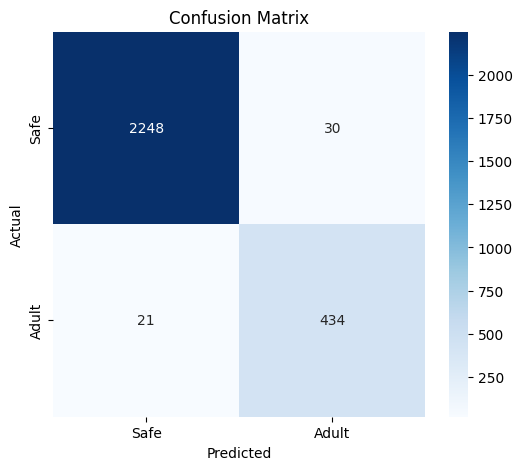

In [39]:
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve

# True labels
y_true = val_labels.values

# ---- CONFUSION MATRIX ----
cm = confusion_matrix(y_true, preds)

print("Confusion Matrix:")
print(cm)

# Plot
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Safe", "Adult"],
            yticklabels=["Safe", "Adult"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# STEP 10 — Threshold Tuning

In [40]:
import tensorflow as tf

probs = tf.nn.softmax(logits, axis=1)[:,1]

threshold = 0.3  # try 0.3 instead of 0.5

preds = (probs > threshold).numpy().astype(int)

print(classification_report(val_labels.values, preds))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2278
           1       0.93      0.97      0.95       455

    accuracy                           0.98      2733
   macro avg       0.96      0.98      0.97      2733
weighted avg       0.98      0.98      0.98      2733



PR AUC: 0.964894174453329


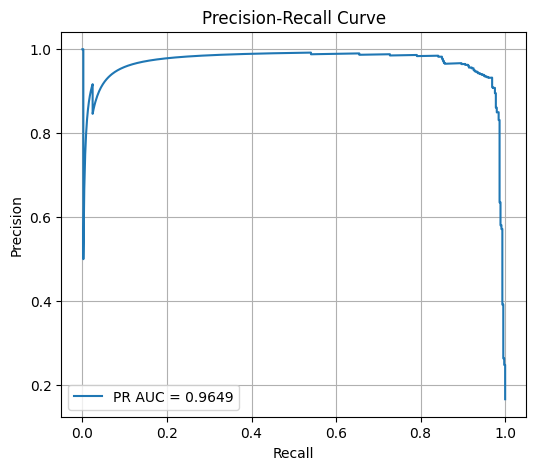

In [41]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

# y_true = true labels
# probs = probability of class 1 (from softmax)

y_scores = probs  # make sure this is class 1 probability

precision, recall, thresholds = precision_recall_curve(y_true, y_scores)

# PR-AUC
pr_auc = average_precision_score(y_true, y_scores)
print("PR AUC:", pr_auc)

# Plot
plt.figure(figsize=(6,5))
plt.plot(recall, precision, label=f"PR AUC = {pr_auc:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid()
plt.show()

AUC Score: 0.9933265154511862


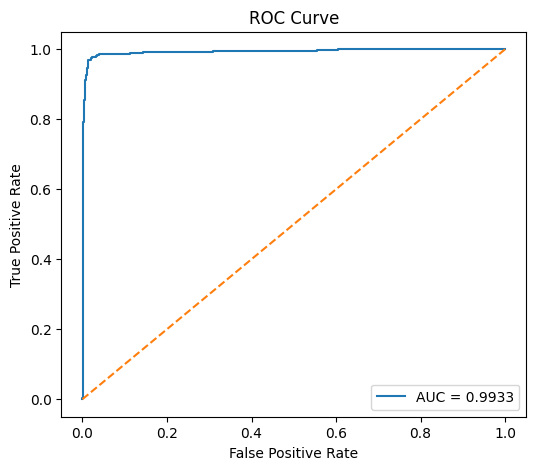

In [42]:
# AUC Score
auc_score = roc_auc_score(y_true, probs)
print("AUC Score:", auc_score)

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_true, probs)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [43]:
# define function
def predict_text(text, threshold=0.3):
    
    inputs = tokenizer(
        text,
        return_tensors="tf",
        truncation=True,
        padding=True,
        max_length=128
    )
    
    outputs = model(**inputs)
    logits = outputs.logits
    
    probs = tf.nn.softmax(logits, axis=1).numpy()[0]
    
    predicted_class = int(probs[1] > threshold)
    
    print("Text:", text)
    print("Safe probability :", probs[0])
    print("Adult probability:", probs[1])
    print("Prediction:", "Adult" if predicted_class == 1 else "Safe")
    
    return predicted_class, probs

# 🔥 CALL FUNCTION
predict_text("This is just a friendly chat.")

Text: This is just a friendly chat.
Safe probability : 0.9984456
Adult probability: 0.0015544596
Prediction: Safe


(0, array([0.9984456 , 0.00155446], dtype=float32))

In [44]:
from transformers import AutoTokenizer

# Load the tokenizer you used for training
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

# Save tokenizer in the same folder as the model
tokenizer.save_pretrained("distilbert_nlp_model")

('distilbert_nlp_model\\tokenizer_config.json',
 'distilbert_nlp_model\\special_tokens_map.json',
 'distilbert_nlp_model\\vocab.txt',
 'distilbert_nlp_model\\added_tokens.json',
 'distilbert_nlp_model\\tokenizer.json')

In [45]:
# Save model
model.save_pretrained("distilbert_nlp_model")

# Save tokenizer
tokenizer.save_pretrained("distilbert_nlp_model")

('distilbert_nlp_model\\tokenizer_config.json',
 'distilbert_nlp_model\\special_tokens_map.json',
 'distilbert_nlp_model\\vocab.txt',
 'distilbert_nlp_model\\added_tokens.json',
 'distilbert_nlp_model\\tokenizer.json')

In [46]:
# save the model
model.save_pretrained("distilbert_nlp_model")

In [47]:
# If you haven’t done this yet:
model.save_weights("distilbert_nlp_model_weights.h5")

# Load Saved Model

In [48]:
import tensorflow as tf
from transformers import TFAutoModelForSequenceClassification, AutoTokenizer

# Load tokenizer (original base tokenizer)
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

# Load your saved model
model = TFAutoModelForSequenceClassification.from_pretrained("distilbert_nlp_model")

Some layers from the model checkpoint at distilbert_nlp_model were not used when initializing TFDistilBertForSequenceClassification: ['dropout_19']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some layers of TFDistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert_nlp_model and are newly initialized: ['dropout_39']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [50]:
import os

print(os.listdir("distilbert_nlp_model"))

['config.json', 'special_tokens_map.json', 'tf_model.h5', 'tokenizer.json', 'tokenizer_config.json', 'vocab.txt']


# Prediction Function

In [49]:
import numpy as np

def predict_text(text, threshold=0.3):
    
    inputs = tokenizer(
        text,
        return_tensors="tf",
        truncation=True,
        padding=True,
        max_length=128
    )
    
    outputs = model(**inputs)
    logits = outputs.logits
    
    probs = tf.nn.softmax(logits, axis=1).numpy()[0]
    
    predicted_class = int(probs[1] > threshold)
    
    print("Text:", text)
    print("Safe probability :", float(probs[0]))
    print("Adult probability:", float(probs[1]))
    print("Prediction:", "Adult" if predicted_class == 1 else "Safe")
    
    return predicted_class, probs

In [54]:
predict_text("look sexy")

Text: look sexy
Safe probability : 0.47111696004867554
Adult probability: 0.5288830399513245
Prediction: Adult


(1, array([0.47111696, 0.52888304], dtype=float32))

In [55]:
predict_text("Hello how are you today?")

Text: Hello how are you today?
Safe probability : 0.996752917766571
Adult probability: 0.0032470389269292355
Prediction: Safe


(0, array([0.9967529 , 0.00324704], dtype=float32))